# Домашнее задание №1: Постановка задачи, выбор метрики и EDA

**Тема:** Классификация эмоциональных состояний человека по данным электроэнцефалограммы (ЭЭГ)

Студент: Пирогова У.А. Группа: U3310

## 1. Постановка задачи

### 1.1 Бизнес-постановка задачи

Разработка системы автоматического распознавания эмоционального состояния человека (негативное, нейтральное, позитивное) на основе сигналов электроэнцефалограммы (ЭЭГ).

**Область применения:**
- Нейроинтерфейсы (BCI — Brain-Computer Interface): адаптивные системы, реагирующие на эмоциональное состояние пользователя;
- Медицина и психология: объективный мониторинг эмоционального фона пациентов;
- UX-исследования: оценка эмоциональной реакции пользователей на продукт;
- Игровая индустрия и VR: адаптация контента под настроение пользователя.

### 1.2 ML-постановка задачи

**Тип задачи:** многоклассовая классификация (3 класса: NEGATIVE, NEUTRAL, POSITIVE).

Входные данные — числовые признаки, извлечённые из ЭЭГ-сигналов (2548 признаков). Целевая переменная — `label` (категориальная, 3 класса).

### 1.3 Набор данных

Используется датасет [EEG Brainwave Dataset: Feeling Emotions](https://www.kaggle.com/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions) с платформы Kaggle.

## 2. Выбор и обоснование метрики

**Основная метрика:** F1-score.

**Обоснование:** В задаче мультиклассовой классификации эмоций все три класса одинаково важны с точки зрения бизнес-применения — нам одинаково критично корректно распознавать как негативные, так и позитивные/нейтральные состояния. F1-score учитывает и точность (precision), и полноту (recall) для каждого класса, усредняя их без учёта размера класса, что делает метрику устойчивой к возможному дисбалансу классов.

**Дополнительные метрики:** Accuracy, Precision, Recall — для полноты картины.

## 3. Разведочный анализ данных (EDA)

### 3.1 Импорт библиотек и загрузка данных

In [1]:
%reset -f
import gc
gc.collect()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import shutil

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
warnings.simplefilter('ignore', category=FutureWarning)
warnings.simplefilter('ignore', category=DeprecationWarning)
%matplotlib inline

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('emotions.csv', encoding='utf-8', delimiter=',')
print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')

Датасет загружен: 2132 строк, 2549 столбцов


### 3.2 Базовые характеристики и статистики

Рассмотрим структуру датасета: типы данных, наличие пропусков, дубликатов, а также описательные статистики.

In [3]:
print('Первые 5 строк:')
df.head()

Первые 5 строк:


mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0      4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1     28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2      8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3     14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4     28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  mean_d_0_a2  mean_d_1_a2  mean_d_2_a2  \
0      -15.70        2.06        3.15         2.15         29.5       -353.0   
1        2.88        3.83       -4.82        25.60         32.8         29.6   
2       90.20       89.90        2.03         7.75         30.1       -441.0   
3        8.82        2.30       -1.97        17.30         32.0       -148.0   
4        3.06       41.40        5.52        26.10         34.3         43.7   

   mean_d_3_a2  mean_d_4_a2  mean_d_5_a  mean_d_6_a  mean_d_7_a  mean_d_8_a  \
0        14.40         21.5        5.98        30.7      -343.0        14.7   
1        21.50         17.4       25.50        31.7        31.5        26.2   
2         9.89         25.3      -68.90        25.3      -481.0       -65.4   
3        20.40         22.8       13.20        31.5      -147.0        16.9   
4        23.70         20.6       -3.87        34.1        43.7       -10.0   

   mean_d_9_a  mean_d_10_a  mean_d_11_a  mean_d_12_a  mean_d_13_a  \
0        27.9         3.17         32.2       -368.0         15.9   
1        32.9        31.80         33.1         33.2         28.5   
2        20.0        79.80         31.0       -408.0         91.9   
3        27.7        15.70         30.7       -142.0         20.7   
4        22.9        59.40         26.7         60.3         64.7   

   mean_d_14_a  mean_d_15_a  mean_d_16_a  mean_d_17_a  mean_d_18_a  \
0         36.4         7.08         28.8       -359.0         17.3   
1         26.8        32.40         34.7         33.8         27.0   
2         29.5        18.80         31.1       -335.0         32.2   
3         22.8        13.60         32.2       -135.0         21.2   
4         26.9        32.30         30.1         33.6         31.6   

   mean_d_19_a  mean_d_20_a  mean_d_21_a  mean_d_22_a  mean_d_23_a  \
0         19.6      -3.8300       -1.230    -10.80000       -0.363   
1         14.2       0.0342        1.100     -1.87000       -4.690   
2         19.9      76.6000        4.850     39.90000       75.300   
3         23.8       4.1500        0.556     -0.35400        3.460   
4         27.7      30.0000        0.276     -0.00677       33.700   

   mean_d_24_a  mean_d_25_a  mean_d_26_a  mean_d_27_a  mean_d_28_a  \
0        -6.41        -1.03       -2.780        14.60       -1.540   
1       -15.40        -6.22       -0.328        -3.53       -6.980   
2         5.27       -72.00       -0.843       -33.00      -82.000   
3        -4.96         1.63        1.330        -5.83       -0.298   
4        -2.36       -33.30        7.640       -16.60      -41.100   

   mean_d_29_a  mean_d_30_a  mean_d_31_a  mean_d_32_a  mean_d_33_a  \
0   -14.900000        -4.94        0.664         5.82       -2.920   
1    -9.370000        -6.85       -1.890        -4.13       -5.460   
2    -4.200000       -11.00       -0.972      -106.00      -22.300   
3     0.000777         3.71       -0.176       -12.10       -0.784   
4    -6.290000        -6.21        4.260        10.10       -7.930   

   mean_d_34_a  mean_d_35_a  mean_d_36_a  mean_d_37_a  mean_d_38_a  \
0         1.90         2.80       -1.550        25.50        -1.18   
1         3.20        -6.25       -1.430        -1.65        -2.28   
2         5.36      -149.00       -5.690       -72.90      -157.00   
3        -1.07        -2.52        0.771        -5.48        -3.75   
4        -7.14       -63.30        7.360       -16.60       -74.80   

   mean_d_39_a  mean_d_40_a  mean_d_41_a  mean_d_42_

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Columns: 2549 entries, mean_0_a to label
dtypes: float64(2548), object(1)
memory usage: 41.5+ MB


Итого имеем датасет из 2132 строк (записей) и 2549 столбцов (2548 числовых (float) признаков + 1 категориальный таргет)


In [8]:
print('Описательные статистики (первые 10 признаков для наглядности):')
df.iloc[:, :10].describe().T

Описательные статистики (первые 10 признаков для наглядности):


,count,mean,std,min,25%,50%,75%,max
mean_0_a,2132.0,15.256914,15.284621,-61.3,6.5775,14.10000,27.700,304.0
mean_1_a,2132.0,27.012462,9.265141,-114.0,26.0750,30.00000,31.400,42.3
mean_2_a,2132.0,-104.975629,206.271960,-970.0,-195.0000,14.95000,29.600,661.0
mean_3_a,2132.0,13.605898,16.874676,-137.0,4.8575,15.40000,26.500,206.0
mean_4_a,2132.0,24.150483,14.187340,-217.0,23.6000,25.20000,26.800,213.0
mean_d_0_a,2132.0,0.025378,17.981796,-218.0,-3.1050,-0.04460,2.920,402.0
mean_d_1_a,2132.0,0.052282,8.509174,-255.0,-1.3400,0.13200,1.540,257.0
mean_d_2_a,2132.0,0.301655,68.098894,-1360.0,-4.0025,0.95750,6.735,1150.0
mean_d_3_a,2132.0,0.036793,17.010031,-203.0,-2.9050,-0.09975,2.535,349.0
mean_d_4_a,2132.0,0.083567,18.935378,-553.0,-2.6225,0.14650,2.870,444.0


Проверим пропуски и дубликаты

In [10]:
# Проверка пропусков
missing = df.isna().sum().sum()
print(f'Общее количество пропущенных значений: {missing}')

# Проверка дубликатов
duplicates = df.duplicated().sum()
print(f'Количество дубликатов: {duplicates}')

Общее количество пропущенных значений: 0
Количество дубликатов: 0


**Вывод:** датасет полностью чистый — нет пропусков и дубликатов. Все 2548 признаков являются числовыми (float), единственный категориальный столбец — целевая переменная `label`. Это упрощает предобработку: не потребуется импутация пропусков или обработка категориальных признаков (кроме целевой переменной)

### 3.3 Анализ целевой переменной

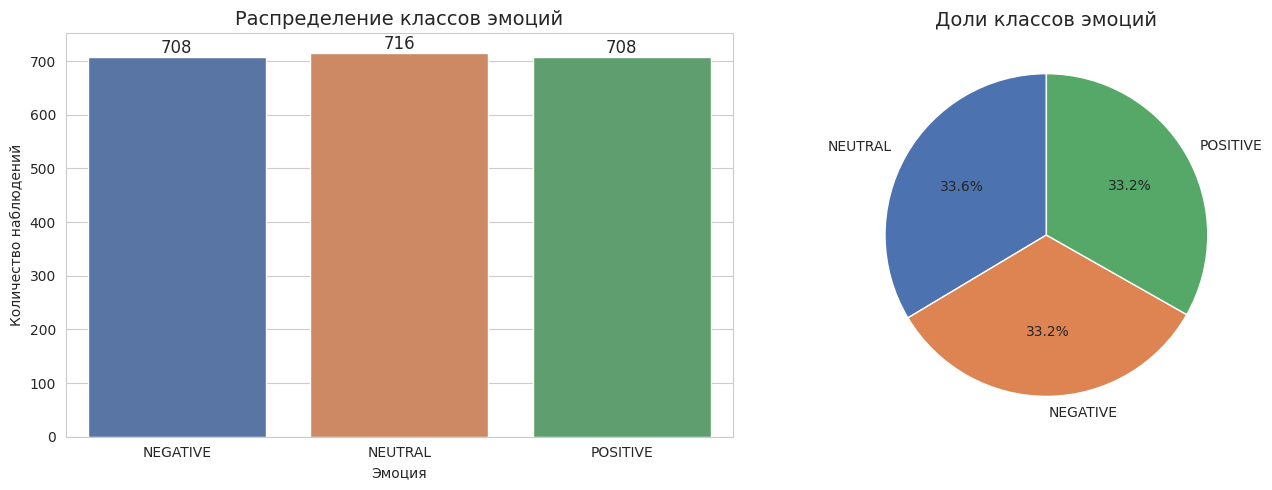

In [14]:
# Визуализация распределения целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['label'].value_counts()
# Столбчатая диаграмма
sns.countplot(data=df, x='label', hue='label', palette='deep', legend=False, ax=axes[0])
axes[0].set_title('Распределение классов эмоций', fontsize=14)
axes[0].set_xlabel('Эмоция')
axes[0].set_ylabel('Количество наблюдений')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Круговая диаграмма
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('deep', 3), startangle=90)
axes[1].set_title('Доли классов эмоций', fontsize=14)

plt.tight_layout()
plt.show()

**Вывод:** Классы распределены равномерно (≈33% на каждый класс). Существенного дисбаланса не наблюдается, что является благоприятным условием для обучения модели. Тем не менее, использование F1 остаётся предпочтительным выбором, так как он не зависит от баланса классов.

### 3.4 Анализ распределений признаков

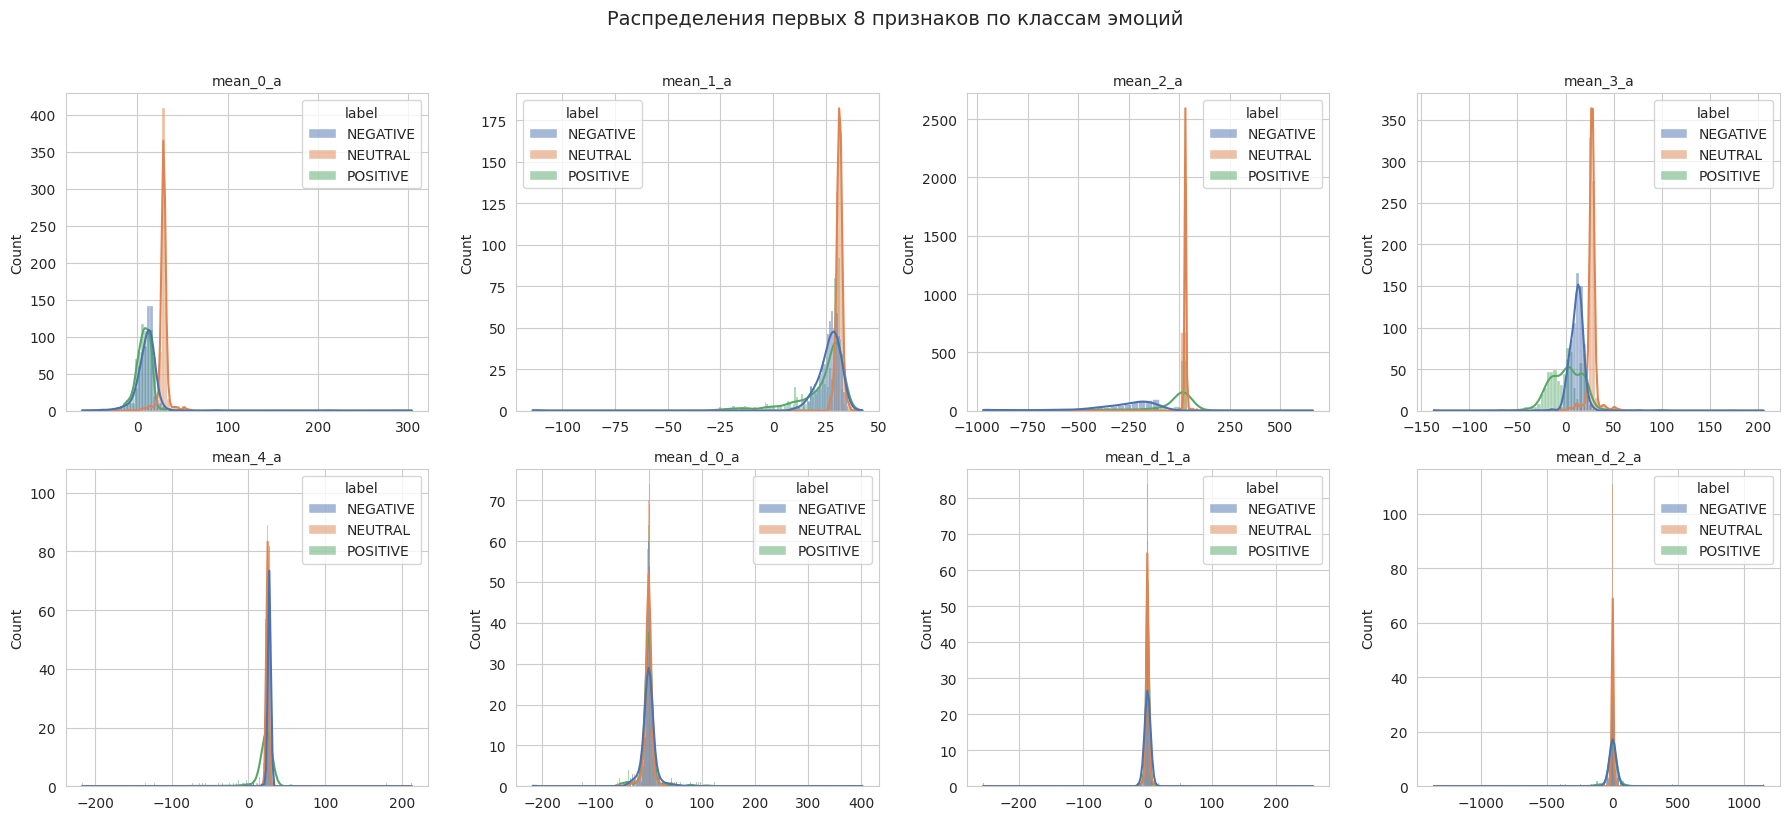

In [17]:
# Возьмём первые 8 признаков для визуализации распределений
sample_features = df.columns[:8].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(sample_features):
    sns.histplot(data=df, x=feat, hue='label', kde=True, palette='deep',
                 alpha=0.5, ax=axes[i], legend=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Распределения первых 8 признаков по классам эмоций', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** Распределения признаков по классам в значительной степени перекрываются — это ожидаемо для данных ЭЭГ, где отдельные признаки имеют слабую дискриминирующую способность. Именно поэтому для эффективной классификации потребуется использование ансамблевых методов или методов понижения размерности (PCA), которые позволят выявить скрытые закономерности в совокупности признаков.

### 3.5 Корреляционный анализ

In [25]:
# Интерактивная heatmap корреляций
corr_20 = df[df.columns[:20]].corr()

fig = px.imshow(
    corr_20,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Корреляционная матрица (первые 20 признаков)',
    aspect='equal'
)
fig.update_layout(width=1000, height=900)
fig.show()

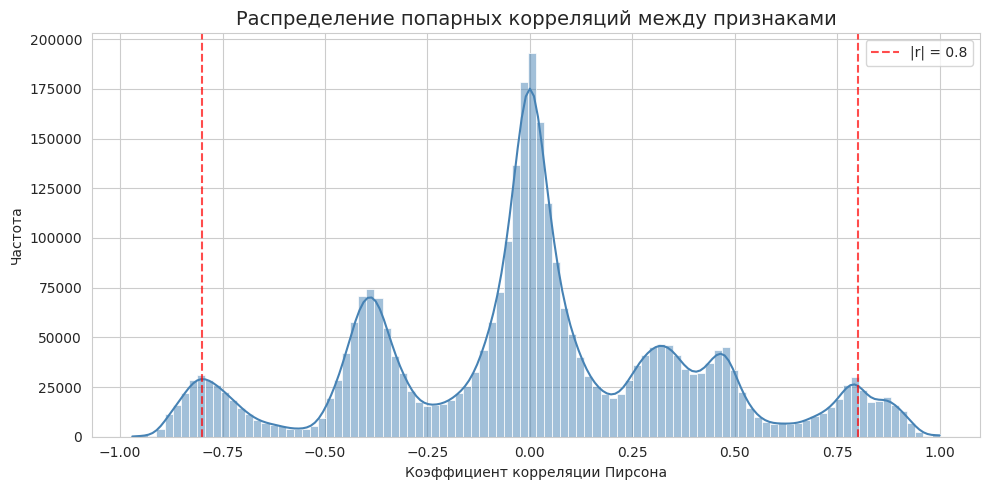

In [24]:
# Распределение корреляций по всему датасету
# (посчитаем все попарные корреляции и построим гистограмму)
full_corr = df.drop(columns='label').corr()
mask = np.triu(np.ones_like(full_corr, dtype=bool), k=1)
corr_values = full_corr.where(mask).stack().values
plt.figure(figsize=(10, 5))
sns.histplot(corr_values, bins=100, kde=True, color='steelblue')
plt.axvline(x=0.8, color='red', linestyle='--', alpha=0.7, label='|r| = 0.8')
plt.axvline(x=-0.8, color='red', linestyle='--', alpha=0.7)
plt.title('Распределение попарных корреляций между признаками', fontsize=14)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** Корреляционная матрица демонстрирует наличие сильно коррелированных пар признаков (например, `mean_2_a` и `mean_d_7_a` с r = 0.99, `mean_2_a` и `mean_d_2_a2` с r = 0.97). Гистограмма попарных корреляций имеет характерную мультимодальную форму: помимо основного пика около нуля, присутствуют выраженные пики вблизи ±0.4–0.5, что говорит о том, что умеренная и сильная корреляция — не единичное явление, а системное свойство данных. Это типично для ЭЭГ-признаков, которые извлекаются из перекрывающихся каналов и частотных диапазонов. Наличие такой мультиколлинеарности является прямым аргументом в пользу применения PCA для снижения размерности: PCA позволит устранить избыточность и сократить число признаков без существенной потери информации.

### 3.6 Анализ главных компонент (PCA)

Учитывая высокую размерность данных (2548 признаков) и наличие мультиколлинеарности, применим PCA для исследования внутренней структуры данных.

In [27]:
# Подготовка данных для PCA
features = df.columns.drop('label')

X = df[features].copy()
y = df['label'].copy()

# Стандартизация обязательна перед PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
# Полный PCA для анализа объяснённой дисперсии
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)

threshold = 0.95
n_components_95 = np.argmax(explained_var >= threshold) + 1

print(f'Для объяснения {threshold*100:.0f}% дисперсии необходимо {n_components_95} компонент из {X_scaled.shape[1]}.')
print(f'Это позволяет сократить размерность в {X_scaled.shape[1] / n_components_95:.1f} раз.')

Для объяснения 95% дисперсии необходимо 168 компонент из 2548.
Это позволяет сократить размерность в 15.2 раз.


In [33]:
# Scree plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(range(1, len(explained_var) + 1)),
    y=explained_var,
    mode='lines',
    name='Кумулятивная дисперсия',
    line=dict(color='steelblue', width=2)
))
fig.add_hline(y=0.95, line_dash='dash', line_color='red',
              annotation_text='95% порог')
fig.add_vline(x=n_components_95, line_dash='dash', line_color='green',
              annotation_text=f'{n_components_95} компонент')
fig.update_layout(
    title='Scree Plot: объяснённая дисперсия PCA',
    xaxis_title='Количество компонент',
    yaxis_title='Кумулятивная объяснённая дисперсия',
    width=1000, height=700
)
fig.show()

**Вывод:** PCA показывает, что ~95% информации содержится в существенно меньшем числе компонент (168) по сравнению с исходными 2548 признаками. Это подтверждает наличие значительной избыточности в данных и обосновывает целесообразность снижения размерности перед обучением модели.

## 4. Выводы

По результатам EDA можно сделать следующие выводы:

1. **Данные чистые:** пропуски и дубликаты отсутствуют, все признаки числовые - требуется минимальная предобработка.

2. **Баланс классов:** классы распределены равномерно (~33% на класс), что позволяет не прибегать к методам балансировки (oversampling/undersampling).

3. **Высокая размерность:** 2548 признаков при 2132 наблюдениях. Соотношение признаков к наблюдениям близко к 1:1, что создаёт риск переобучения. Необходимо применять снижение размерности (PCA) и регуляризацию.

4. **Мультиколлинеарность:** среди признаков обнаружено значительное количество высоко коррелированных пар, что является дополнительным аргументом в пользу PCA.

5. **План предобработки для следующего этапа:**
   - Масштабирование признаков + возможно  нормализация для исправления распределений;
   - Снижение размерности через PCA;
   - Разбиение на train/val/test с сохранением распределений классов.